# echofac3 v2: Training STgram-MFN (Hyperparameter Fixed)

**Perbedaan dari v1:**
- ArcFace scale `s=12.0` (bukan 32.0) — disesuaikan untuk 4 kelas mesin
- ArcFace margin `m=0.3` (bukan 0.5) — lebih stabil untuk few-class
- Epoch: 100 (bukan 50)
- Gradient clipping lebih ketat: 2.0 (bukan 5.0)
- Warmup LR: 10 epoch pertama pakai LR rendah untuk stabilitas awal

**Aktifkan T4 GPU di Kaggle Settings!**

In [1]:
import os, gc, json, time, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.backends.cudnn.benchmark = True
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/(1024**3):.1f} GB')


Device: cuda
GPU: Tesla T4
VRAM: 14.6 GB


In [2]:
# ===== KONFIGURASI =====
MACHINE_TYPE = 'fan'   # fan | pump | slider | valve
FEAT_DIR = '/kaggle/input/notebooks/muhammadmuhibin/echofac2/features'
BATCH_SIZE   = 64
EPOCHS       = 100
LR           = 5e-4
WEIGHT_DECAY = 5e-4
EMBED_DIM    = 256

# ArcFace YANG BENAR untuk 4 kelas:
ARC_S = 12.0   # Scale kecil untuk few-class (bukan 32)
ARC_M = 0.3    # Margin lebih rendah untuk stabilitas

WARMUP_EPOCHS = 10  # 10 epoch pertama LR rendah
OUT_MODEL = f'/kaggle/working/stgram_mfn_{MACHINE_TYPE}_v2.pt'

print(f'Machine  : {MACHINE_TYPE.upper()}')
print(f'ArcFace  : s={ARC_S}, m={ARC_M}  (optimized untuk 4 kelas)')
print(f'Epochs   : {EPOCHS} | Warmup: {WARMUP_EPOCHS} epoch')


Machine  : FAN
ArcFace  : s=12.0, m=0.3  (optimized untuk 4 kelas)
Epochs   : 100 | Warmup: 10 epoch


In [3]:
class MIMIIDataset(Dataset):
    def __init__(self, machine, feat_dir, cond='normal'):
        path = os.path.join(feat_dir, f'{machine}_{cond}.pt')
        data = torch.load(path, map_location='cpu')
        self.feats  = data['features']
        self.labels = data['labels']
        self.n_cls  = int(self.labels.max().item()) + 1
        print(f'Loaded {machine}/{cond}: N={len(self.feats)}, n_classes={self.n_cls}')
    def __len__(self): return len(self.feats)
    def __getitem__(self, idx):
        f = self.feats[idx]
        return f[0:1], f[1:2], self.labels[idx]

train_ds = MIMIIDataset(MACHINE_TYPE, FEAT_DIR, 'normal')
N_CLASSES = train_ds.n_cls
train_dl  = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
print(f'DataLoader: {len(train_dl)} batches | {N_CLASSES} machine IDs')


Loaded fan/normal: N=4075, n_classes=4
DataLoader: 64 batches | 4 machine IDs


In [4]:
class ConvBNPReLU(nn.Module):
    def __init__(self, ic, oc, k=3, s=1, p=1, g=1):
        super().__init__()
        self.net = nn.Sequential(nn.Conv2d(ic, oc, k, s, p, groups=g, bias=False), nn.BatchNorm2d(oc), nn.PReLU(oc))
    def forward(self, x): return self.net(x)

class DepthwiseSep(nn.Module):
    def __init__(self, ic, oc, s=1):
        super().__init__()
        self.net = nn.Sequential(ConvBNPReLU(ic, ic, s=s, g=ic), ConvBNPReLU(ic, oc, k=1, p=0))
    def forward(self, x): return self.net(x)

class MobileFaceNet(nn.Module):
    def __init__(self, ed=256):
        super().__init__()
        self.enc = nn.Sequential(
            ConvBNPReLU(1, 32, s=2), DepthwiseSep(32, 64),
            DepthwiseSep(64, 128, s=2), DepthwiseSep(128, 128),
            DepthwiseSep(128, 256, s=2), DepthwiseSep(256, 256),
            DepthwiseSep(256, 512, s=2), nn.AdaptiveAvgPool2d(1)
        )
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(512, ed), nn.BatchNorm1d(ed))
    def forward(self, x): return self.head(self.enc(x))

class ArcFace(nn.Module):
    def __init__(self, ed, nc, s=12.0, m=0.3):
        super().__init__()
        self.s, self.m = s, m
        self.W = nn.Parameter(torch.FloatTensor(nc, ed))
        nn.init.xavier_uniform_(self.W)
        self.cos_m = math.cos(m); self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m); self.mm = math.sin(math.pi - m) * m
    def forward(self, feat, labels):
        cos = F.normalize(feat, 1) @ F.normalize(self.W, 1).T
        sin = (1.0 - cos.clamp(-1+1e-7, 1-1e-7) ** 2).sqrt()
        phi = cos * self.cos_m - sin * self.sin_m
        phi = torch.where(cos > self.th, phi, cos - self.mm)
        one_hot = F.one_hot(labels, cos.shape[1]).float()
        return F.cross_entropy((one_hot * phi + (1.0 - one_hot) * cos) * self.s, labels)

class STgramMFN(nn.Module):
    def __init__(self, nc, ed=256):
        super().__init__()
        self.mel    = MobileFaceNet(ed)
        self.tgram  = MobileFaceNet(ed)
        self.fuse   = nn.Sequential(nn.Linear(ed*2, ed), nn.BatchNorm1d(ed), nn.PReLU(ed))
        self.arc    = ArcFace(ed, nc, ARC_S, ARC_M)
    def forward(self, mel, tg, labels=None):
        feat = F.normalize(self.fuse(torch.cat([self.mel(mel), self.tgram(tg)], dim=1)), dim=1)
        if labels is not None: return feat, self.arc(feat, labels)
        return feat

model = STgramMFN(N_CLASSES, EMBED_DIM).to(device)
tp = sum(p.numel() for p in model.parameters())
print(f'STgram-MFN on {device} | {tp:,} params ({tp/1e6:.2f}M)')
print(f'ArcFace: s={ARC_S}, m={ARC_M}  (calibrated for {N_CLASSES} classes)')


STgram-MFN on cuda | 938,368 params (0.94M)
ArcFace: s=12.0, m=0.3  (calibrated for 4 classes)


In [5]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS  # warmup linear
    progress = (epoch - WARMUP_EPOCHS) / (EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))  # cosine decay

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler('cuda')

best_loss = float('inf')
losses    = []
t0        = time.time()

print(f'Training {MACHINE_TYPE.upper()} | {EPOCHS} epochs | LR warmup {WARMUP_EPOCHS} ep')
print('-' * 60)

for ep in range(1, EPOCHS + 1):
    model.train(); epoch_loss = 0.0
    for mel, tg, lab in train_dl:
        mel, tg, lab = mel.to(device), tg.to(device), lab.to(device)
        optimizer.zero_grad()
        with autocast('cuda'):
            _, loss = model(mel, tg, lab)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        scaler.step(optimizer); scaler.update()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_dl)
    losses.append(avg); scheduler.step()
    if avg < best_loss:
        best_loss = avg
        torch.save({'epoch': ep, 'model_state': model.state_dict(), 'best_loss': best_loss,
                    'machine': MACHINE_TYPE, 'n_classes': N_CLASSES, 'embed_dim': EMBED_DIM,
                    'config': {'ARC_S': ARC_S, 'ARC_M': ARC_M}}, OUT_MODEL)
    if ep % 10 == 0 or ep == 1:
        lr_now = optimizer.param_groups[0]['lr']
        elapsed = (time.time() - t0) / 60
        tag = ' <- BEST' if avg == best_loss else ''
        print(f'Ep {ep:3d}/{EPOCHS} | Loss: {avg:.4f} | LR: {lr_now:.2e} | {elapsed:.1f}min{tag}')

print(f'\nTraining selesai! Best loss: {best_loss:.4f} -> {OUT_MODEL}')
if torch.cuda.is_available():
    print(f'Peak VRAM: {torch.cuda.max_memory_allocated()/(1024**3):.2f} GB')


Training FAN | 100 epochs | LR warmup 10 ep
------------------------------------------------------------
Ep   1/100 | Loss: 4.6315 | LR: 1.00e-04 | 0.5min <- BEST
Ep  10/100 | Loss: 4.0651 | LR: 5.00e-04 | 1.0min <- BEST
Ep  20/100 | Loss: 0.2434 | LR: 4.85e-04 | 1.6min <- BEST
Ep  30/100 | Loss: 0.2308 | LR: 4.42e-04 | 2.1min
Ep  40/100 | Loss: 0.1321 | LR: 3.75e-04 | 2.7min
Ep  50/100 | Loss: 0.1088 | LR: 2.93e-04 | 3.3min
Ep  60/100 | Loss: 0.0828 | LR: 2.07e-04 | 3.9min <- BEST
Ep  70/100 | Loss: 0.0820 | LR: 1.25e-04 | 4.4min <- BEST
Ep  80/100 | Loss: 0.1568 | LR: 5.85e-05 | 5.0min
Ep  90/100 | Loss: 0.0906 | LR: 1.51e-05 | 5.6min
Ep 100/100 | Loss: 0.1132 | LR: 0.00e+00 | 6.2min

Training selesai! Best loss: 0.0807 -> /kaggle/working/stgram_mfn_fan_v2.pt
Peak VRAM: 0.96 GB


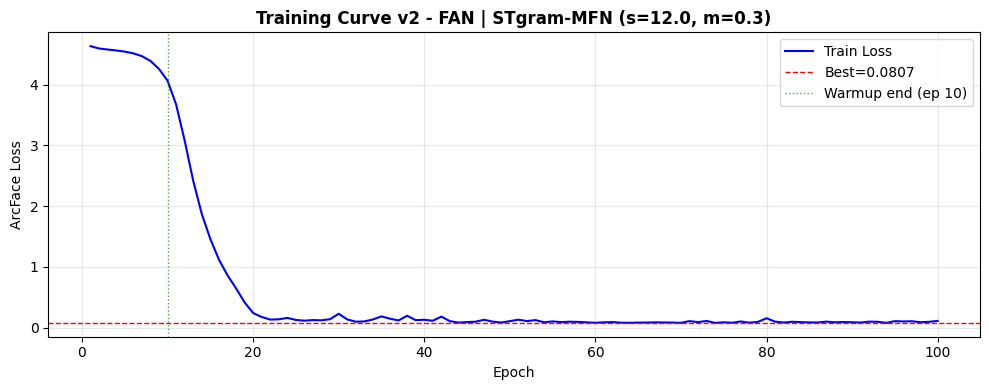

echofac3 v2 FAN SELESAI!


In [6]:
plt.figure(figsize=(10, 4))
plt.plot(range(1, len(losses)+1), losses, 'b-', lw=1.5, label='Train Loss')
plt.axhline(best_loss, color='r', ls='--', lw=1, label=f'Best={best_loss:.4f}')
plt.axvline(WARMUP_EPOCHS, color='g', ls=':', lw=1, alpha=0.7, label=f'Warmup end (ep {WARMUP_EPOCHS})')
plt.xlabel('Epoch'); plt.ylabel('ArcFace Loss')
plt.title(f'Training Curve v2 - {MACHINE_TYPE.upper()} | STgram-MFN (s={ARC_S}, m={ARC_M})', fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f'/kaggle/working/curve_{MACHINE_TYPE}_v2.png', dpi=150)
plt.show()
print(f'echofac3 v2 {MACHINE_TYPE.upper()} SELESAI!')
